# Combined (Adult + Pediatric) — EBGM-Filtered Overview
## Demographics, Reporting & Severity Overview

**Dataset:** Combined (Adult + Pediatric) — EBGM-filtered signals only (EBGM05 > 2)  
**Source:** `data/notebook/output/signal_analysis/filtered_ebgm/`  
**Output:** `data/notebook/output/top_terms_adult_and_ped_ebgm/`

In [3]:
# ============================================================
# Setup + Data Loading
# ============================================================
from pathlib import Path
import pandas as pd
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from IPython.display import display, Markdown
import warnings
warnings.filterwarnings("ignore")

plt.rcParams.update({"figure.dpi": 120, "font.size": 11})
sns.set_style("whitegrid")

ROOT = Path("..").resolve()
SIGNAL_OUT = ROOT / "data" / "notebook" / "output" / "signal_analysis"
FULL_DATA_ROOT = ROOT / "data" / "output"

# ── Dataset configuration ──────────────────────────────────────────────
MODE = "combined"
PRR_FILE = SIGNAL_OUT / "filtered_ebgm" / "adult_and_ped_ebgm_filtered.parquet"
SOURCE_PATHS = [
    FULL_DATA_ROOT / "Adult" / "patient_report_reporter_drug_reaction_full_data.parquet",
    FULL_DATA_ROOT / "Pediatric" / "patient_report_reporter_drug_reaction_full_data.parquet",
]
COHORT_LABEL = "Combined (Adult + Pediatric)"

OUTPUT_DIR = ROOT / "data" / "notebook" / "output" / "top_terms_adult_and_ped_ebgm"
(OUTPUT_DIR / "figures").mkdir(parents=True, exist_ok=True)
(OUTPUT_DIR / "tables").mkdir(parents=True, exist_ok=True)

# ── Load EBGM-filtered pair list ────────────────────────────────────────
if not PRR_FILE.exists():
    raise FileNotFoundError(f"Run signal_filtering_and_stratification.ipynb first: {PRR_FILE}")
prr_pairs = pl.read_parquet(PRR_FILE)
print(f"EBGM-filtered pairs:     {prr_pairs.height:,}")

pair_key_set = set(zip(prr_pairs["drug"].to_list(), prr_pairs["event"].to_list()))
print(f"Unique (drug, event):   {len(pair_key_set):,}")

# ── Load full event data ───────────────────────────────────────────────
print(f"\nLoading full event data for {COHORT_LABEL} ...")
dfs = [pd.read_parquet(p) for p in SOURCE_PATHS]
df_full = pd.concat(dfs, ignore_index=True) if len(dfs) > 1 else dfs[0]
del dfs
print(f"Full event rows:        {len(df_full):,}")

# ── Subset to EBGM-filtered pairs ───────────────────────────────────────
_key = df_full["medicinal_product"].astype(str) + "||" + df_full["reaction_meddrapt"].astype(str)
_pair_keys = {f"{d}||{e}" for d, e in pair_key_set}
df = df_full[_key.isin(_pair_keys)].copy()
del df_full, _key, _pair_keys
print(f"Filtered event rows:    {len(df):,}  (rows belonging to PRR-passed pairs)")

print(f"\nUnique reports:       {df['safetyreportid'].nunique():,}")
print(f"Unique drugs:           {df['medicinal_product'].nunique():,}")
print(f"Unique reactions:       {df['reaction_meddrapt'].nunique():,}")

EBGM-filtered pairs:     413,752
Unique (drug, event):   413,752

Loading full event data for Combined (Adult + Pediatric) ...
Full event rows:        18,766,336
Filtered event rows:    7,038,244  (rows belonging to PRR-passed pairs)

Unique reports:       1,778,401
Unique drugs:           51,126
Unique reactions:       1,613


---
# A — Demographics, Reporting & Severity

Overview of the Combined (Adult + Pediatric) cohort (EBGM-filtered signals only).

## A.1 — Dataset Summary Table

In [4]:
# Dataset overview table
summary_rows = [
    {"Metric": "Filtered event rows",          "Value": f"{len(df):,}"},
    {"Metric": "Unique reports (safetyreportid)", "Value": f"{df['safetyreportid'].nunique():,}"},
    {"Metric": "Unique drugs (medicinal_product)", "Value": f"{df['medicinal_product'].nunique():,}"},
    {"Metric": "Unique reactions (PT)",        "Value": f"{df['reaction_meddrapt'].nunique():,}"},
    {"Metric": "Unique (drug, event) pairs",   "Value": f"{len(pair_key_set):,}"},
    {"Metric": "Date range (receive_date)",    "Value": f"{pd.to_datetime(df['receive_date']).min().date()} → {pd.to_datetime(df['receive_date']).max().date()}"},
    {"Metric": "Female %",                     "Value": f"{(df['patient_sex'] == 'Female').sum() / df['safetyreportid'].nunique() * 100:.1f}%" if len(df) > 0 else "N/A"},
    {"Metric": "Male %",                       "Value": f"{(df['patient_sex'] == 'Male').sum() / df['safetyreportid'].nunique() * 100:.1f}%" if len(df) > 0 else "N/A"},
]
summary_df = pd.DataFrame(summary_rows)
display(summary_df)
summary_df.to_csv(OUTPUT_DIR / "tables" / "dataset_summary.csv", index=False)

,Metric,Value
0,Filtered event rows,"7,038,244"
1,Unique reports (safetyreportid),"1,778,401"
2,Unique drugs (medicinal_product),"51,126"
3,Unique reactions (PT),"1,613"
4,"Unique (drug, event) pairs","413,752"
5,Date range (receive_date),2014-01-01 → 2025-12-31
6,Female %,261.9%
7,Male %,128.0%


## A.2 — Age Distribution

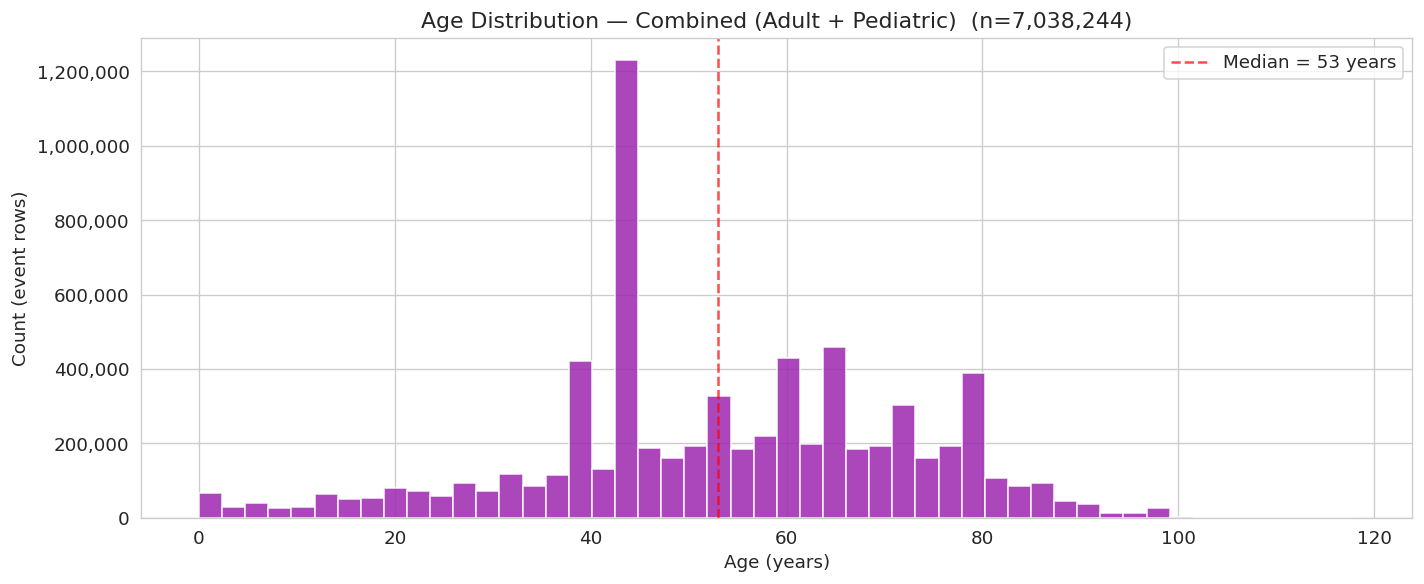

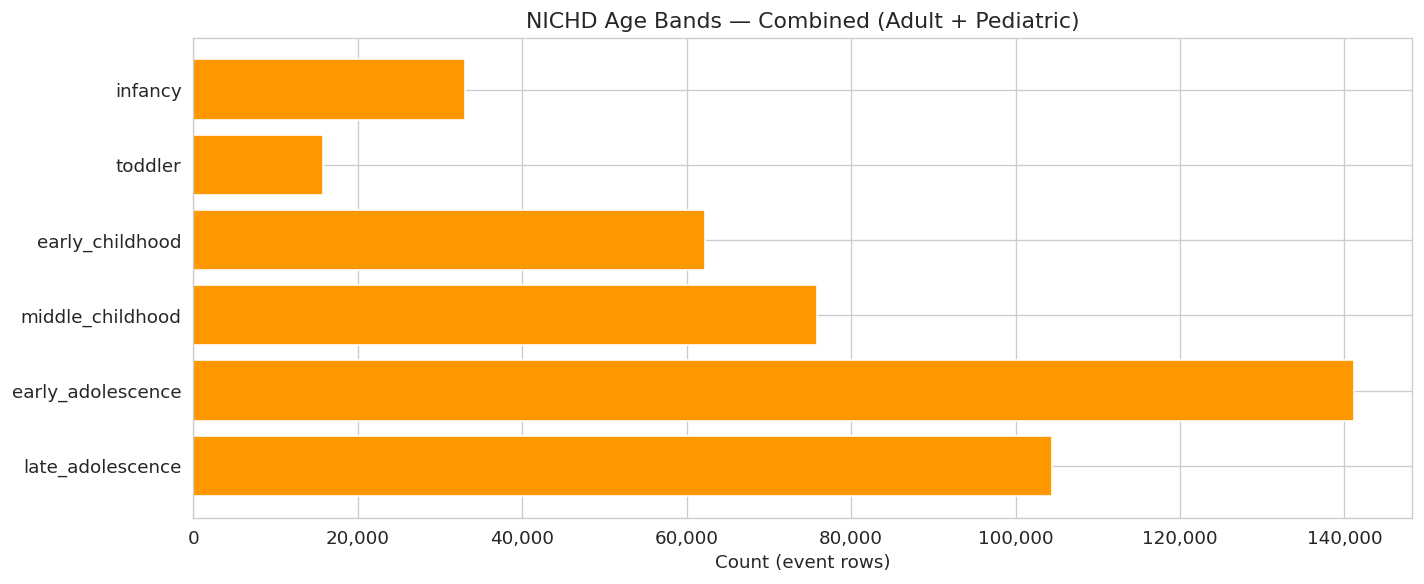

In [5]:
fig, ax = plt.subplots(figsize=(12, 5))
ages = df.loc[df["age_years"].notna(), "age_years"]
if len(ages) > 0:
    ax.hist(ages, bins=50, color="#2196F3" if MODE == "adult" else "#FF9800" if MODE == "pediatric" else "#9C27B0",
            edgecolor="white", alpha=0.85)
    ax.set_xlabel("Age (years)")
    ax.set_ylabel("Count (event rows)")
    ax.set_title(f"Age Distribution — {COHORT_LABEL}  (n={len(ages):,})")
    ax.axvline(ages.median(), color="red", linestyle="--", alpha=0.7,
               label=f"Median = {ages.median():.0f} years")
    ax.legend()
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "figures" / "age_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

# NICHD bands (pediatric only)
if "nichd" in df.columns and df["nichd"].notna().any():
    nichd_order = ["infancy", "toddler", "early_childhood", "middle_childhood", "early_adolescence", "late_adolescence"]
    nichd_counts = df["nichd"].value_counts().reindex(nichd_order).dropna()
    if len(nichd_counts) > 0:
        fig, ax = plt.subplots(figsize=(12, 5))
        ax.barh(nichd_counts.index.tolist()[::-1], nichd_counts.values[::-1],
                color="#FF9800", edgecolor="white")
        ax.set_xlabel("Count (event rows)")
        ax.set_title(f"NICHD Age Bands — {COHORT_LABEL}")
        ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x:,.0f}"))
        plt.tight_layout()
        plt.savefig(OUTPUT_DIR / "figures" / "nichd_bands.png", dpi=150, bbox_inches="tight")
        plt.show()

## A.3 — Sex Distribution

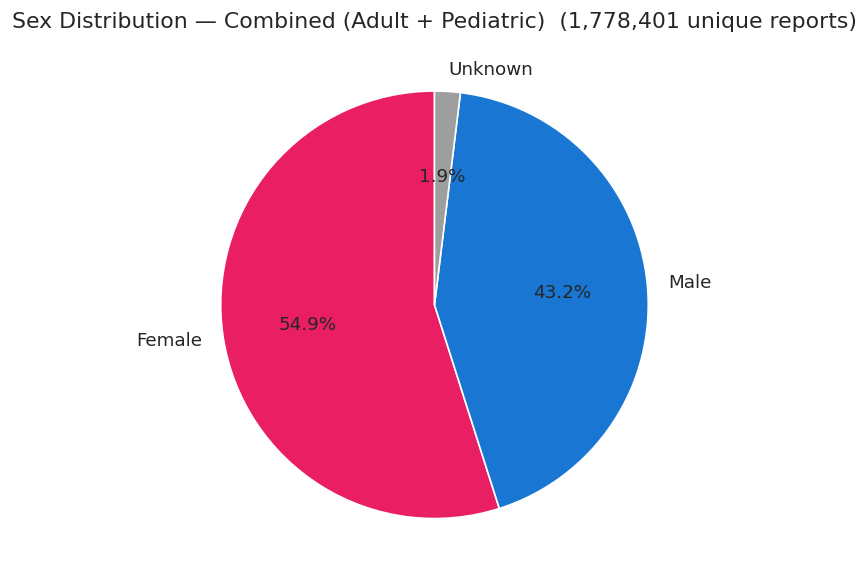

,Sex,Count,%
0,Female,976425,54.90
1,Male,767551,43.16
2,Unknown,34425,1.94


In [6]:
sex_counts = df.groupby("safetyreportid")["patient_sex"].first().value_counts()
fig, ax = plt.subplots(figsize=(8, 5))
colors_map = {"Female": "#E91E63", "Male": "#1976D2", "Unknown": "#9E9E9E"}
colors = [colors_map.get(s, "#757575") for s in sex_counts.index]
ax.pie(sex_counts.values, labels=sex_counts.index, autopct="%1.1f%%",
       colors=colors, startangle=90)
ax.set_title(f"Sex Distribution — {COHORT_LABEL}  ({sex_counts.sum():,} unique reports)")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "figures" / "sex_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

display(pd.DataFrame({"Sex": sex_counts.index, "Count": sex_counts.values,
                      "%": (sex_counts.values / sex_counts.sum() * 100).round(2)}))

## A.4 — Reports Over Time

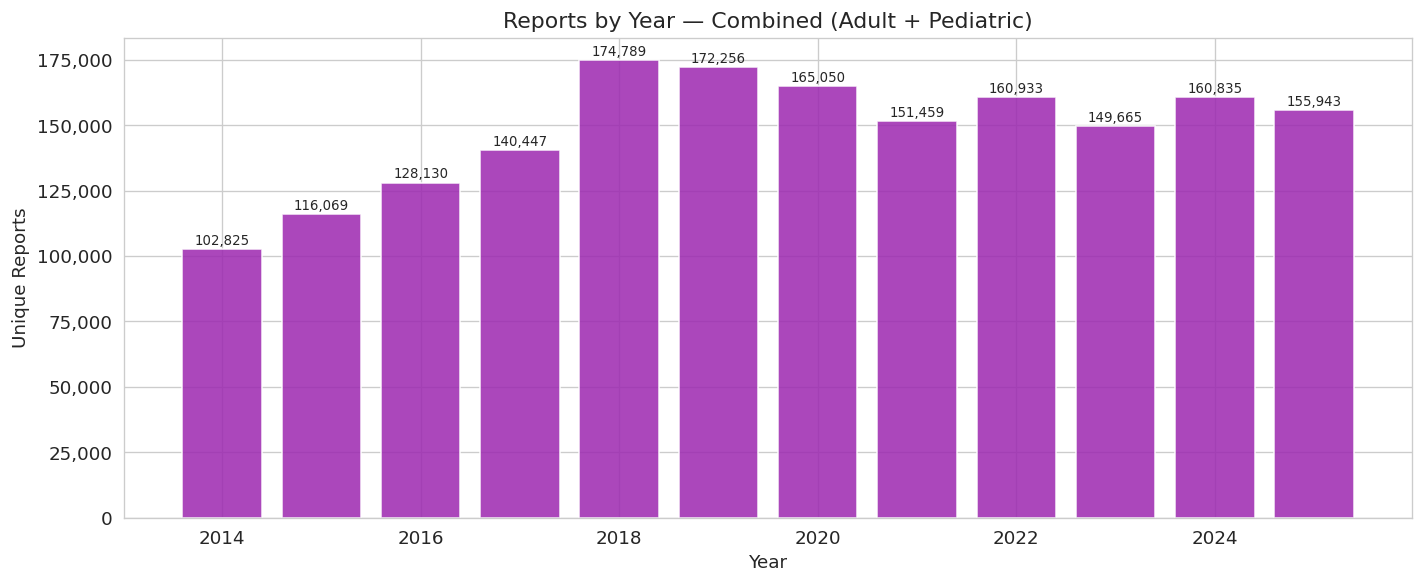

In [7]:
df["_year"] = pd.to_datetime(df["receive_date"]).dt.year
year_reports = df.groupby("_year")["safetyreportid"].nunique().sort_index()

fig, ax = plt.subplots(figsize=(12, 5))
color_map = {"adult": "#2196F3", "pediatric": "#FF9800", "combined": "#9C27B0"}
ax.bar(year_reports.index, year_reports.values,
       color=color_map.get(MODE, "#757575"), edgecolor="white", alpha=0.85)
ax.set_xlabel("Year")
ax.set_ylabel("Unique Reports")
ax.set_title(f"Reports by Year — {COHORT_LABEL}")
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x:,.0f}"))
for x, y in zip(year_reports.index, year_reports.values):
    ax.text(x, y + max(year_reports.values)*0.01, f"{y:,}",
            ha="center", fontsize=8)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "figures" / "reports_by_year.png", dpi=150, bbox_inches="tight")
plt.show()

## A.5 — Top Reporter Countries

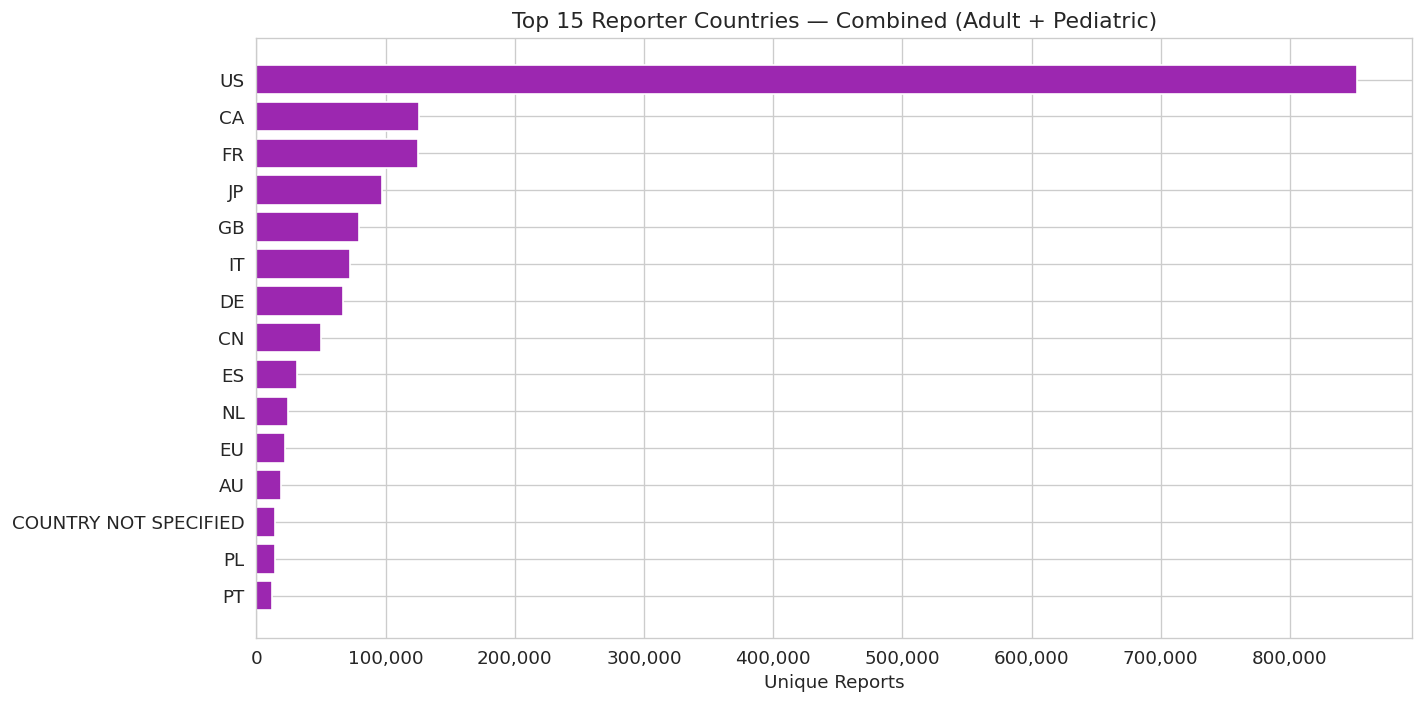

In [8]:
country_counts = (
    df.groupby("safetyreportid")["reporter_country"].first()
    .value_counts().head(15)
)

fig, ax = plt.subplots(figsize=(12, 6))
color_map = {"adult": "#2196F3", "pediatric": "#FF9800", "combined": "#9C27B0"}
ax.barh(country_counts.index[::-1], country_counts.values[::-1],
        color=color_map.get(MODE, "#757575"), edgecolor="white")
ax.set_xlabel("Unique Reports")
ax.set_title(f"Top 15 Reporter Countries — {COHORT_LABEL}")
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "figures" / "reporter_country.png", dpi=150, bbox_inches="tight")
plt.show()

## A.6 — Severity Breakdown

Report-level flags (death, hospitalization, etc.) for Combined (Adult + Pediatric).

**Severity Flags (per report, flags may overlap):**

,Category,Reports,%
5,other,863282,48.54
1,hospitalization,657644,36.98
6,non_serious,406336,22.85
0,death,253104,14.23
2,life_threatening,119304,6.71
3,disabling,37050,2.08
4,congenital_anomali,5181,0.29


**Serious vs Non-serious:**

,Status,Reports,%
0,Serious (any flag = 1),1372065,77.15
1,Non-serious (all flags = 0),406336,22.85
2,Total,1778401,100.00


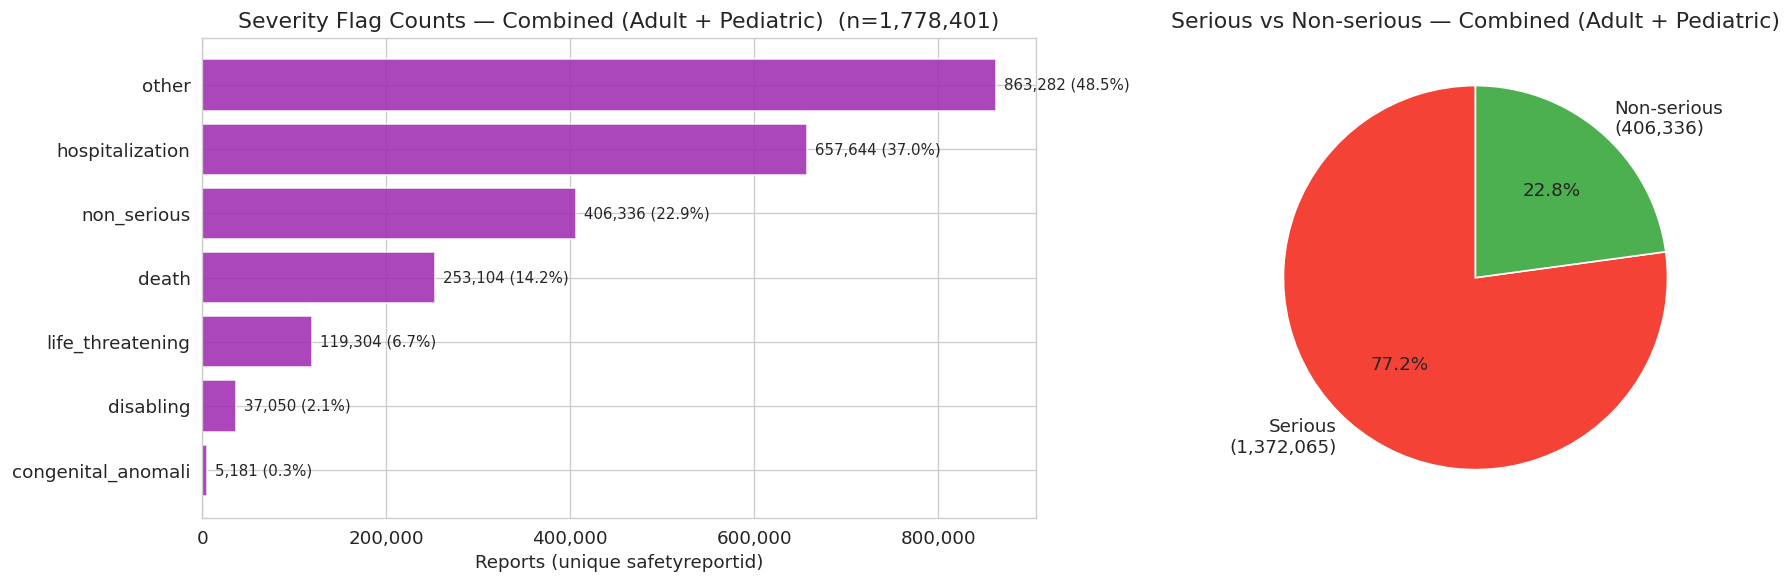

In [9]:
# ============================================================
# Severity Breakdown
# ============================================================
SEVERITY_FLAGS = ["death", "hospitalization", "life_threatening", "disabling", "congenital_anomali", "other"]
available = [f for f in SEVERITY_FLAGS if f in df.columns]

# Per-report (unique safetyreportid)
rep_df = df.drop_duplicates(subset=["safetyreportid"])[["safetyreportid"] + available]
n_reports = len(rep_df)

# Count reports flagged by each severity column
flag_counts = {f: int((rep_df[f] == 1).sum()) for f in available}

# non_serious: reports where ALL severity flags = 0
has_any_flag = (rep_df[available] == 1).any(axis=1)
non_serious_count = int((~has_any_flag).sum())
serious_count = int(has_any_flag.sum())

# Table: flag breakdown (including non_serious)
flag_rows = [{"Category": f, "Reports": flag_counts[f], "%": round(flag_counts[f]/n_reports*100, 2)} for f in available]
flag_rows.append({"Category": "non_serious", "Reports": non_serious_count, "%": round(non_serious_count/n_reports*100, 2)})
flag_df = pd.DataFrame(flag_rows).sort_values("Reports", ascending=False)
display(Markdown("**Severity Flags (per report, flags may overlap):**"))
display(flag_df)
flag_df.to_csv(OUTPUT_DIR / "tables" / "severity_flags.csv", index=False)

# Table: serious vs non-serious
proportion_df = pd.DataFrame([
    {"Status": "Serious (any flag = 1)", "Reports": serious_count, "%": round(serious_count/n_reports*100, 2)},
    {"Status": "Non-serious (all flags = 0)", "Reports": non_serious_count, "%": round(non_serious_count/n_reports*100, 2)},
    {"Status": "Total", "Reports": n_reports, "%": 100.00},
])
display(Markdown("**Serious vs Non-serious:**"))
display(proportion_df)
proportion_df.to_csv(OUTPUT_DIR / "tables" / "serious_vs_non_serious.csv", index=False)

# Plot 1: Severity flag counts
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
color_map_mode = {"adult": "#2196F3", "pediatric": "#FF9800", "combined": "#9C27B0"}
mode_color = color_map_mode.get(MODE, "#757575")

# flag bar chart
cats = flag_df["Category"].tolist()[::-1]
counts = flag_df["Reports"].tolist()[::-1]
pcts = flag_df["%"].tolist()[::-1]
axes[0].barh(cats, counts, color=mode_color, alpha=0.85, edgecolor="white")
for i, (c, p) in enumerate(zip(counts, pcts)):
    axes[0].text(c + max(counts)*0.01, i, f"{c:,} ({p:.1f}%)", va="center", fontsize=9)
axes[0].set_xlabel("Reports (unique safetyreportid)")
axes[0].set_title(f"Severity Flag Counts — {COHORT_LABEL}  (n={n_reports:,})")
axes[0].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x:,.0f}"))

# serious vs non-serious pie
axes[1].pie([serious_count, non_serious_count],
            labels=[f"Serious\n({serious_count:,})", f"Non-serious\n({non_serious_count:,})"],
            autopct="%1.1f%%", colors=["#F44336", "#4CAF50"], startangle=90,
            wedgeprops=dict(edgecolor="white"))
axes[1].set_title(f"Serious vs Non-serious — {COHORT_LABEL}")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "figures" / "severity_breakdown.png", dpi=150, bbox_inches="tight")
plt.show()

## Summary — Combined (Adult + Pediatric)

Key descriptive statistics exported to:
- `top_terms_adult_and_ped_ebgm/tables/dataset_summary.csv`
- `top_terms_adult_and_ped_ebgm/tables/severity_breakdown.csv`
- `top_terms_adult_and_ped_ebgm/figures/*.png`